DATA COLLECTION - We used a Predictive Maintenance Dataset (AI4I 2020) from kaggle based on a milling machine. For other machines, sensor readings would have to be gotten and model trained based on that sensor for our prediction

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [8]:
import os
import kagglehub

# Download latest version
path = kagglehub.dataset_download("stephanmatzka/predictive-maintenance-dataset-ai4i-2020")
print(os.listdir(path))

print("Path to dataset files:", path)
df = pd.read_csv(path + "/ai4i2020.csv")
df.head()

Using Colab cache for faster access to the 'predictive-maintenance-dataset-ai4i-2020' dataset.
['ai4i2020.csv']
Path to dataset files: /kaggle/input/predictive-maintenance-dataset-ai4i-2020


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [10]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [11]:
df.shape

(10000, 14)

In [12]:
df['Machine failure'].value_counts(normalize=True)

,proportion
Machine failure,
0,0.9661
1,0.0339


There is a very massive imbalance in this dataset, we would take care of that later on.

DATA CLEANING

In [13]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [14]:
df.duplicated().sum()

np.int64(0)

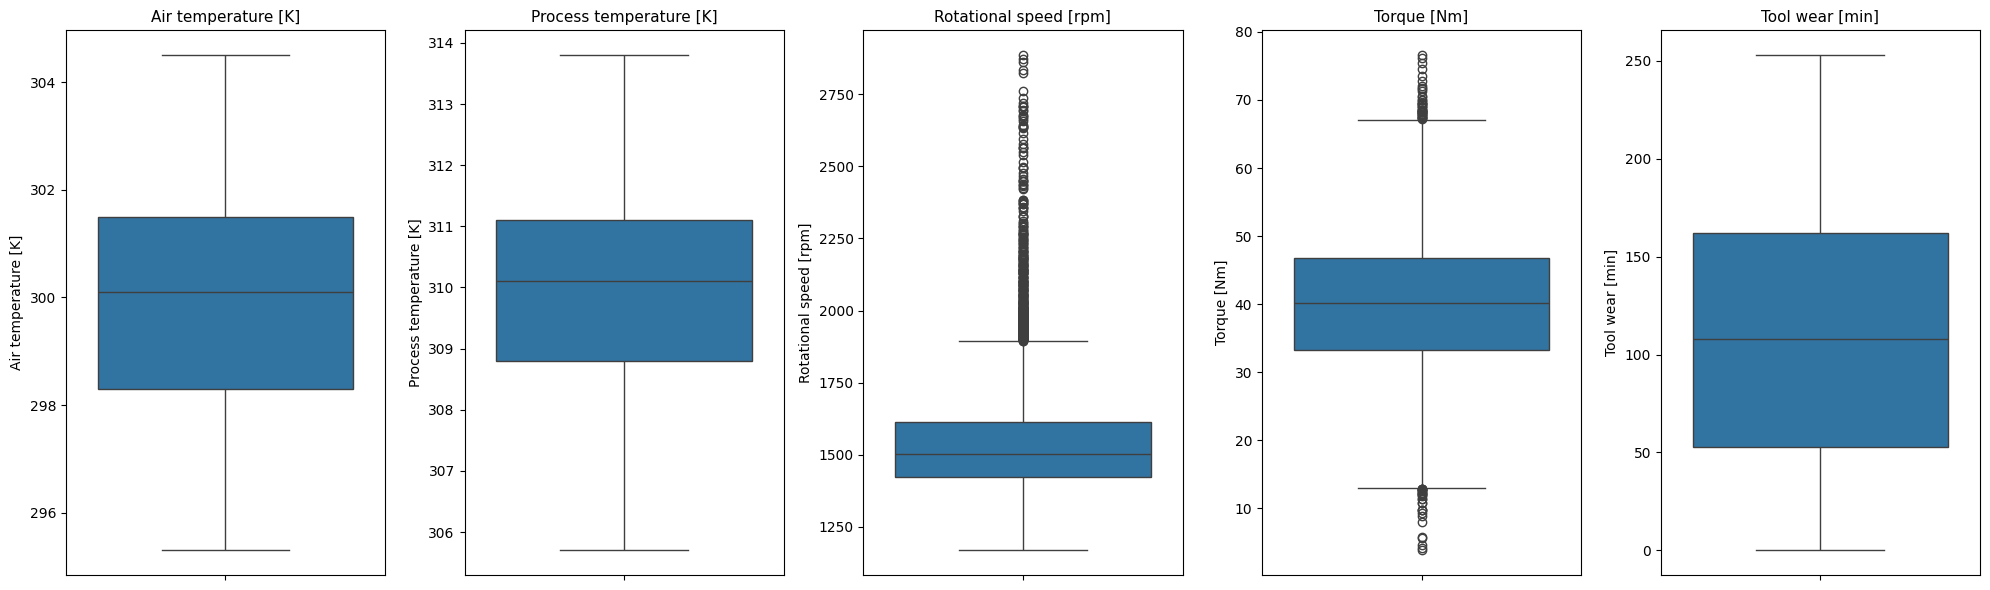

In [15]:
numeric_cols = ["Air temperature [K]", "Process temperature [K]",
                 "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 6))

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=11)

plt.tight_layout()
plt.show()


We have outliers in our Rotational speed and Torque column, so we deal with that before moving on.

In [16]:
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers, {outliers['Machine failure'].sum()} are failures")

Air temperature [K]: 0 outliers, 0 are failures
Process temperature [K]: 0 outliers, 0 are failures
Rotational speed [rpm]: 418 outliers, 35 are failures
Torque [Nm]: 69 outliers, 62 are failures
Tool wear [min]: 0 outliers, 0 are failures


Outliers were particuklarly found in Rotational Speed and Torque columns. We are not removing outliers because we carried out an investigation and and these values were strongly linked to actual machine failure rather than sensor error. So, we decided to keep them.

In [17]:
df=df.drop(["UDI", "Product ID", "TWF", "HDF", "PWF", "OSF", "RNF"], axis=1)
df.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure'],
      dtype='object')

UDI and Product ID was dropped because they are not useful features in our dataset. TWF, HDF, PWF, OSF, and RNF were dropped because they cause data leakage to our work.

EXPLORATORY DATA ANALYSIS

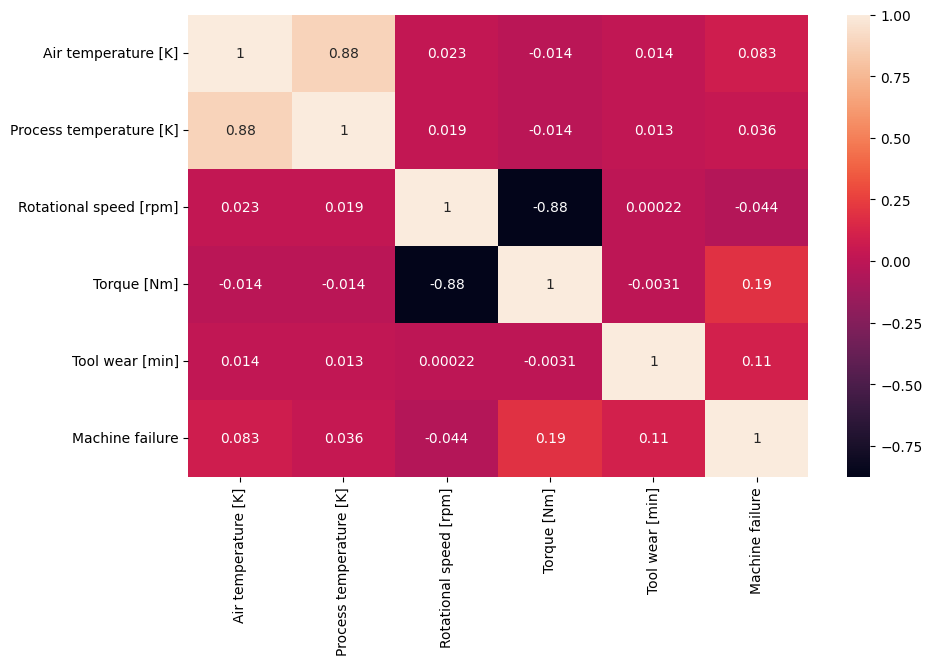

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

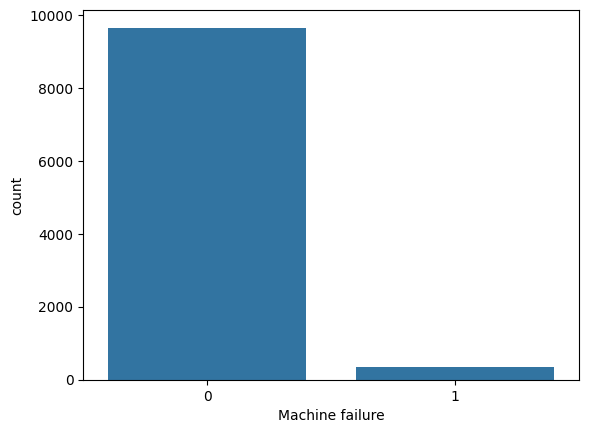

In [19]:
sns.countplot(data=df, x="Machine failure")
plt.show()

In [20]:
# Encoding categorical column
df = pd.get_dummies(df, columns=["Type"], dtype=int)

In [21]:
# Feature Engineering
df["temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["power"] = df["Rotational speed [rpm]"] * df["Torque [Nm]"] * (2*3.14159/60)
df["wear_torque_ratio"] = df["Tool wear [min]"] / (df["Torque [Nm]"] + 1)

We engineered three features to make a good impact while building our model.

1. Temperature difference was engineered because it captures how efficiently the machine is dissipating heat.

2. Power was engineered because it represents the actual mechanical work the machine is doing at any moment. Power = Speed * Torque.

3. Wear Torque ratio was engineered to encode known physical failure mechanisms (heat dissipation, power failure, tool overstrain) rather than relying on raw sensor values alone, giving the model direct signal aligned with how these machines actually fail.

In [22]:
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]

In [23]:
# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

MODEL BUILDING

In [25]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=20, min_samples_leaf=10, random_state=42, n_jobs=-1, class_weight="balanced")
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=10, min_samples_split=20, n_jobs=-1,
                       random_state=42)

In [26]:
y_pred_rf = rf.predict(X_test_scaled)
y_pred_rf[:5]

array([0, 0, 0, 0, 0])

In [27]:
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]
y_proba_rf[:5]

array([3.81214052e-01, 9.46688687e-04, 4.32709482e-01, 2.12596822e-04,
       2.04937470e-01])

In [28]:
rf_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).head(10)

display(rf_importance)

,feature,importance
3,Torque [Nm],0.217978
2,Rotational speed [rpm],0.209953
9,power,0.176369
4,Tool wear [min],0.173604
8,temp_diff,0.085675
10,wear_torque_ratio,0.066172
0,Air temperature [K],0.037102
1,Process temperature [K],0.023833
6,Type_L,0.005489
7,Type_M,0.002956


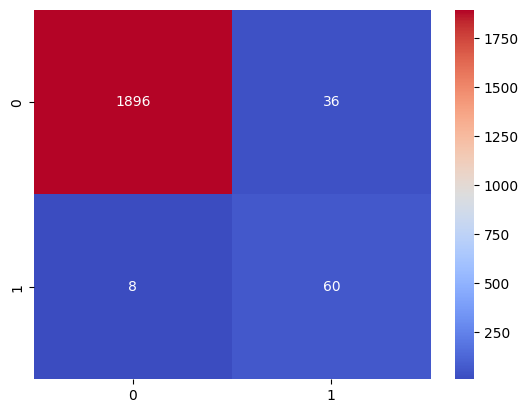

In [29]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm")
plt.show()

In [30]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1932
           1       0.62      0.88      0.73        68

    accuracy                           0.98      2000
   macro avg       0.81      0.93      0.86      2000
weighted avg       0.98      0.98      0.98      2000



We prioritized recall over precision because in predictive maintenance, a missed failure (false negative) causes unplanned downtime, while a false alarm only costs a routine inspection — an acceptable trade for a safety-critical early-warning system.

In [31]:
df_test = X_test.copy()
df_test["Machine failure (actual)"] = y_test.values
df_test["risk_score"] = (y_proba_rf * 100).round(1)

In [32]:
def risk_range(score):
  if score <= 15:
    return "Safe"
  elif score <= 25:
    return "Watch closely"
  elif score <= 75:
      return "High risk"
  else:
    return "Critical"

df_test["risk_level"] = df_test["risk_score"].apply(risk_range)

action_map = {
    "Safe": "Keep running",
    "Watch closely": "Schedule inspection",
    "High risk": "Inspect soon",
    "Critical": "Stop and repair immediately"
}
df_test["recommended_action"] = df_test["risk_level"].map(action_map)

In [33]:
pd.crosstab(df_test["Machine failure (actual)"], df_test["risk_level"])

risk_level,Critical,High risk,Safe,Watch closely
Machine failure (actual),,,,
0,4,144,1719,65
1,51,13,3,1


Threshold tuning reduced missed failures from 18% to 6% of actual failure cases. While this increased false-positive inspections (7.7% of healthy machines flagged 'High risk'), the vast majority of false alarms fell in the 'inspect soon' category rather than 'stop and repair immediately' — meaning the operational cost of tuning toward higher recall was concentrated in low-disruption scheduled inspections rather than costly emergency shutdowns.

In [34]:
# Saving our model
import joblib
joblib.dump(rf, "risk_model.pkl")
joblib.dump(sc, "scaler.pkl")

['scaler.pkl']

In [39]:
!pip install streamlit --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 81.4 MB/s eta 0:00:00


In [41]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import numpy as np

# ============================================================
# PAGE CONFIG
# ============================================================
st.set_page_config(
    page_title="Predictive Maintenance Risk Dashboard",
    page_icon="⚙️",
    layout="wide"
)

# ============================================================
# LOAD MODEL + SCALER (cached so it only loads once)
# ============================================================
@st.cache_resource
def load_model():
    model = joblib.load("risk_model.pkl")
    scaler = joblib.load("scaler.pkl")
    return model, scaler

model, scaler = load_model()

def engineer_features(df):
    df = df.copy()
    df["temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
    df["power"] = df["Rotational speed [rpm]"] * df["Torque [Nm]"] * (2 * 3.14159 / 60)
    df["wear_torque_ratio"] = df["Tool wear [min]"] / (df["Torque [Nm]"] + 1)
    return df

# ============================================================
# RISK BAND LOGIC (your tuned thresholds)
# ============================================================
def risk_category(score):
    if score <= 15:
        return "Safe"
    elif score <= 45:
        return "Watch closely"
    elif score <= 75:
        return "High risk"
    else:
        return "Critical"


ACTION_MAP = {
    "Safe": "Keep running",
    "Watch closely": "Schedule inspection",
    "High risk": "Inspect soon",
    "Critical": "Stop and repair immediately"
}

COLOR_MAP = {
    "Safe": "#2ecc71",
    "Watch closely": "#f1c40f",
    "High risk": "#e67e22",
    "Critical": "#e74c3c"
}

REQUIRED_COLUMNS = [
    "Type", "Air temperature [K]", "Process temperature [K]",
    "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"
]

# ============================================================
# SIDEBAR — machine identity + upload
# ============================================================
st.sidebar.title("⚙️ Controls")

machine_names = st.sidebar.text_area(
    "Optional: Machine names (one per row, matching upload order)",
    placeholder="Crusher 1\nRaw Mill 2\nKiln 1\n..."
)

uploaded_file = st.sidebar.file_uploader(
    "Upload machine sensor readings (CSV)", type="csv"
)

st.sidebar.markdown("---")
st.sidebar.caption(
    "Required columns: " + ", ".join(REQUIRED_COLUMNS)
)

# ============================================================
# MAIN HEADER
# ============================================================
st.title("🏭 Predictive Maintenance & Reliability Early-Warning Dashboard")
st.caption("DCP Engineering Challenge — Track 2: Predictive Maintenance and Reliability Early-Warning System")

# ============================================================
# MAIN LOGIC
# ============================================================
if uploaded_file is None:
    st.info("👈 Upload a CSV of machine sensor readings to generate risk scores.")
    with st.expander("See expected CSV format"):
        example = pd.DataFrame({
            "Type": ["M", "L", "H"],
            "Air temperature [K]": [298.1, 298.2, 298.4],
            "Process temperature [K]": [308.6, 308.7, 309.0],
            "Rotational speed [rpm]": [1551, 1408, 1400],
            "Torque [Nm]": [42.8, 46.3, 60.1],
            "Tool wear [min]": [0, 3, 210]
        })
        st.dataframe(example)
    st.stop()

# --- Read uploaded file ---
try:
    raw_df = pd.read_csv(uploaded_file)
except Exception as e:
    st.error(f"Could not read the uploaded file: {e}")
    st.stop()

# --- Validate columns ---
missing = [c for c in REQUIRED_COLUMNS if c not in raw_df.columns]
if missing:
    st.error(f"Missing required column(s): {missing}")
    st.stop()

# --- Attach machine names ---
if machine_names.strip():
    names_list = [n.strip() for n in machine_names.split("\n") if n.strip()]
    if len(names_list) == len(raw_df):
        raw_df.insert(0, "Machine", names_list)
    else:
        st.warning("Number of machine names doesn't match number of rows — using generic IDs instead.")
        raw_df.insert(0, "Machine", [f"Machine {i+1}" for i in range(len(raw_df))])
else:
    raw_df.insert(0, "Machine", [f"Machine {i+1}" for i in range(len(raw_df))])

# --- Feature engineering ---
df_fe = engineer_features(raw_df)

# --- One-hot encode Type to match training ---
df_fe = pd.get_dummies(df_fe, columns=["Type"], dtype=int)

# Ensure all Type dummy columns the model expects exist (fill missing with 0)
for col in ["Type_H", "Type_L", "Type_M"]:
    if col not in df_fe.columns:
        df_fe[col] = 0

# --- Build feature matrix in the exact order the model was trained on ---
feature_cols = scaler.feature_names_in_ if hasattr(scaler, "feature_names_in_") else None
if feature_cols is not None:
    X_new = df_fe[feature_cols]
else:
    st.error("Scaler is missing feature name metadata — re-save scaler with a fitted DataFrame.")
    st.stop()

# --- Scale + predict ---
X_scaled = scaler.transform(X_new)
failure_prob = model.predict_proba(X_scaled)[:, 1]

# --- Build results table ---
results = raw_df[["Machine"] + REQUIRED_COLUMNS].copy()
results["risk_score"] = (failure_prob * 100).round(1)
results["risk_level"] = results["risk_score"].apply(risk_category)
results["recommended_action"] = results["risk_level"].map(ACTION_MAP)
results = results.sort_values("risk_score", ascending=False).reset_index(drop=True)

# ============================================================
# SUMMARY METRICS
# ============================================================
col1, col2, col3, col4 = st.columns(4)
counts = results["risk_level"].value_counts()
col1.metric("🟢 Safe", int(counts.get("Safe", 0)))
col2.metric("🟡 Watch closely", int(counts.get("Watch closely", 0)))
col3.metric("🟠 High risk", int(counts.get("High risk", 0)))
col4.metric("🔴 Critical", int(counts.get("Critical", 0)))

st.markdown("---")

# ============================================================
# CRITICAL ALERTS BANNER
# ============================================================
critical = results[results["risk_level"] == "Critical"]
if len(critical) > 0:
    st.error(f"🚨 {len(critical)} machine(s) flagged CRITICAL — immediate attention required: "
              + ", ".join(critical["Machine"].tolist()))

# ============================================================
# MAIN TABLE (color-coded)
# ============================================================
st.subheader("Machine Risk Overview")

def highlight_risk(row):
    color = COLOR_MAP.get(row["risk_level"], "white")
    return [f"background-color: {color}; color: white" if col == "risk_level" else "" for col in row.index]

st.dataframe(
    results.style.apply(highlight_risk, axis=1),
    use_container_width=True,
    height=450
)

# ============================================================
# DOWNLOAD BUTTON
# ============================================================
csv_out = results.to_csv(index=False).encode("utf-8")
st.download_button(
    "📥 Download risk report (CSV)",
    data=csv_out,
    file_name="risk_report.csv",
    mime="text/csv"
)

# ============================================================
# RISK SCORE DISTRIBUTION CHART
# ============================================================
st.subheader("Risk Score Distribution")
st.bar_chart(results.set_index("Machine")["risk_score"])


Writing app.py


In [42]:
with open("requirements.txt", "w") as f:
    f.write("streamlit\npandas\nscikit-learn\njoblib\nnumpy\n")